In [167]:
## The goal of this notebook is to study the applicability of private (non-)membership proof delegation
## in a stateless blockchain application. The empirical data is taken from here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm
import matplotlib.colors as colors

In [169]:
## Transaction per second that we want to simulate
## We roughly both want to capture Bitcoin (7 tps), Ethereum's throguhput with L2s (100 tps roughly) and VISA/Mastercard (10k tps)
tps = [2**i for i in range(1, 7)]
## Offline-time interval length (this is the offline period length that we can support)
server_time = [
    2**i for i in range(1, 20, 4)
]  ## in hours (the PSN server is running for this many hours to do its job)

In [170]:
## Bitcoin's empirical coin age follows a power-law distribution
## See the data and measurements here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/
## This power-law distribution can be approximated with the following line on a log-log scale
intercept = -1.4159
slope = -0.9550
## To ease calculations let's just compute with the average of this distribution
average_coin_age_days = (
    162  ## in days (this is a rough estimation given the empirical data above)
)
## median_coin_age_days = 40 //average 162
average_coin_age_hours = average_coin_age_days * 24
average_coin_age_seconds = average_coin_age_hours * 60 * 60  ## in seconds
miliSecondsInHour = 3600000
hoursInMonth = 731

In [171]:
tx3_large_cost_per_hour = 0.208  # in USD, from https://calculator.aws/#/createCalculator/ec2-enhancement on 2026-04-09

In [172]:
bilinear_running_times = np.array(
    [
        2.47304631552381,
        3.0441974239947087,
        4.546898213214285,
        5.980404200000001,
        8.7904001,
        16.4246749,
        22.6448084,
        33.3012292,
    ],
    dtype=float,
)  ## in miliseconds

x_bilinear = np.arange(len(bilinear_running_times)) + 3
y_bilinear = np.log2(bilinear_running_times)

bilinear_slope_runtimes, bilinear_intercept_runtimes = np.polyfit(
    x_bilinear, y_bilinear, 1
)
y_bilinear_pred = bilinear_slope_runtimes * x_bilinear + bilinear_intercept_runtimes

print(x_bilinear.tolist())
print(y_bilinear.tolist())
print(f"bilinear_intercept_runtimes = {bilinear_intercept_runtimes:.6f}")
print(f"bilinear_slope_runtimes = {bilinear_slope_runtimes:.6f}")

[3, 4, 5, 6, 7, 8, 9, 10]
[1.3062892589558386, 1.606061924341518, 2.1848827082974016, 2.58024299573253, 3.1359288319385725, 4.037792909891618, 4.501108427539275, 5.057503525277447]
bilinear_intercept_runtimes = -0.573928
bilinear_slope_runtimes = 0.557716


In [173]:
print(tps)

[2, 4, 8, 16, 32, 64]


In [174]:
## Bilinear membership proof-delegation
noOfThreads = 8  ## number of threads at the AWS server machine
crs_length = (
    2**28
)  ## currently, this is the largest Powers-of-tau trusted setup that one could use in an application without relying on an entirely new trusted setup ceremony
g1_group_element_size = 384  ## in bits
bilinear_upd_cost = np.zeros((len(tps), len(server_time)))
bilinear_comm_complexity = np.zeros((len(tps), len(server_time)))
for i in range(0, len(tps)):
    for j in range(0, len(server_time)):
        ## for each coin, there were this many new coins added to the UTXO set meanwhile it had not been spent
        necessaryUpdatesPerCoin = average_coin_age_seconds * tps[i]
        if (
            necessaryUpdatesPerCoin < crs_length
        ):  ## otherwise, it would not even be possible to do the membership proof update
            ## Runtime fit is in log2-space; convert prediction back to milliseconds.
            runtime_per_update_ms = 2 ** (
                bilinear_slope_runtimes * (math.log2(necessaryUpdatesPerCoin))
                + bilinear_intercept_runtimes
            )
            updates_per_threads = (tps[i] * runtime_per_update_ms) / noOfThreads
            ## the runtime above were given in miliseconds, thus we need to convert them to hour
            upd_cost_per_hour = (
                updates_per_threads / miliSecondsInHour
            )  ## the workload can be done in parallel
            bilinear_upd_cost[i, j] = (
                upd_cost_per_hour * tx3_large_cost_per_hour * server_time[j]
            )  ## let's assume the server is running for 1 year=12 months
            bilinear_comm_complexity[i, j] = (
                server_time[j] * 0.000013 * tps[i]
            )  ## in PB. for each user a client needs to communicate 12.885GB=384*(2**28) bits
bilinear_upd_cost

array([[2.76252061e-04, 4.42003298e-03, 7.07205276e-02, 1.13152844e+00,
        1.81044551e+01],
       [8.13251335e-04, 1.30120214e-02, 2.08192342e-01, 3.33107747e+00,
        5.32972395e+01],
       [2.39410968e-03, 3.83057549e-02, 6.12892078e-01, 9.80627325e+00,
        1.56900372e+02],
       [7.04795789e-03, 1.12767326e-01, 1.80427722e+00, 2.88684355e+01,
        4.61894968e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]])

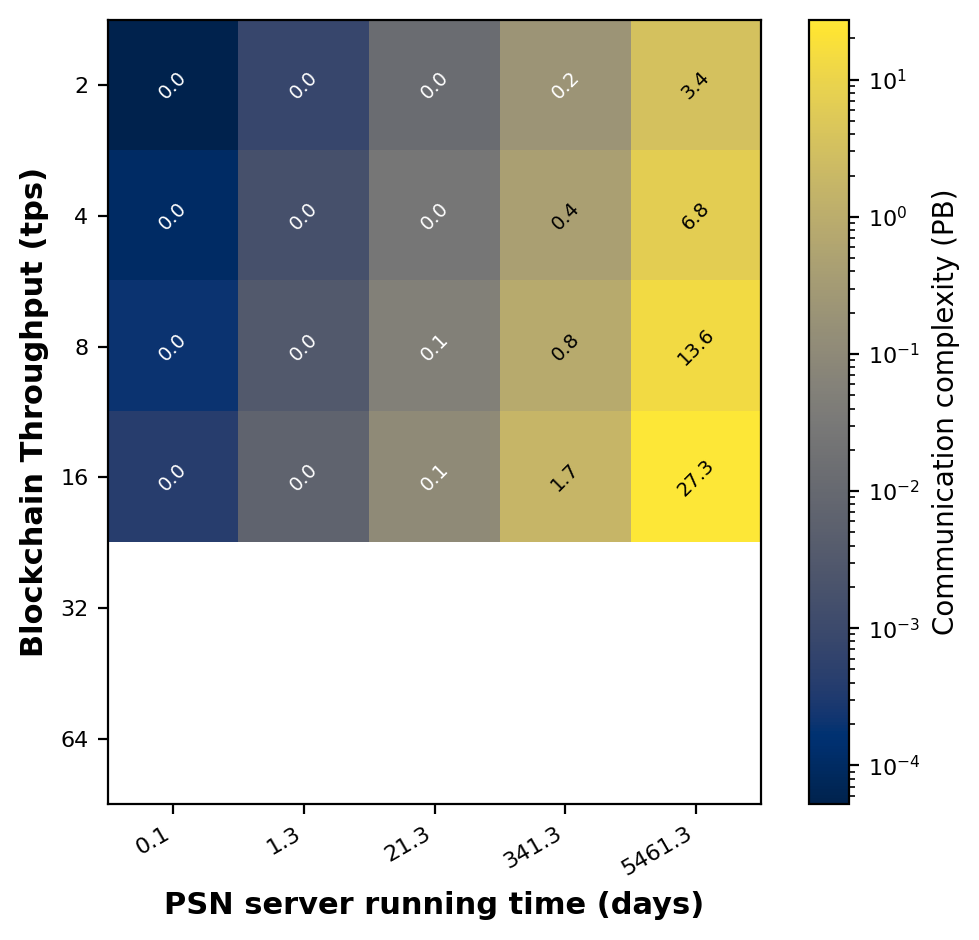

In [175]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

comm_for_plot = np.where(bilinear_comm_complexity > 0, bilinear_comm_complexity, np.nan)
vmin = float(np.nanmin(comm_for_plot))
vmax = float(np.nanmax(comm_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    comm_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.1f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

# Add subtle cell boundaries for easier reading in print.
ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = bilinear_comm_complexity[i, j]
        if value <= 0:
            continue

        label = f"{round(value, 2):.1f}"  # if value >= 1 else f"{round(value, 2):.1e}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Communication complexity (PB)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_bilinear_comm_complexity.pdf", bbox_inches="tight")
plt.show()

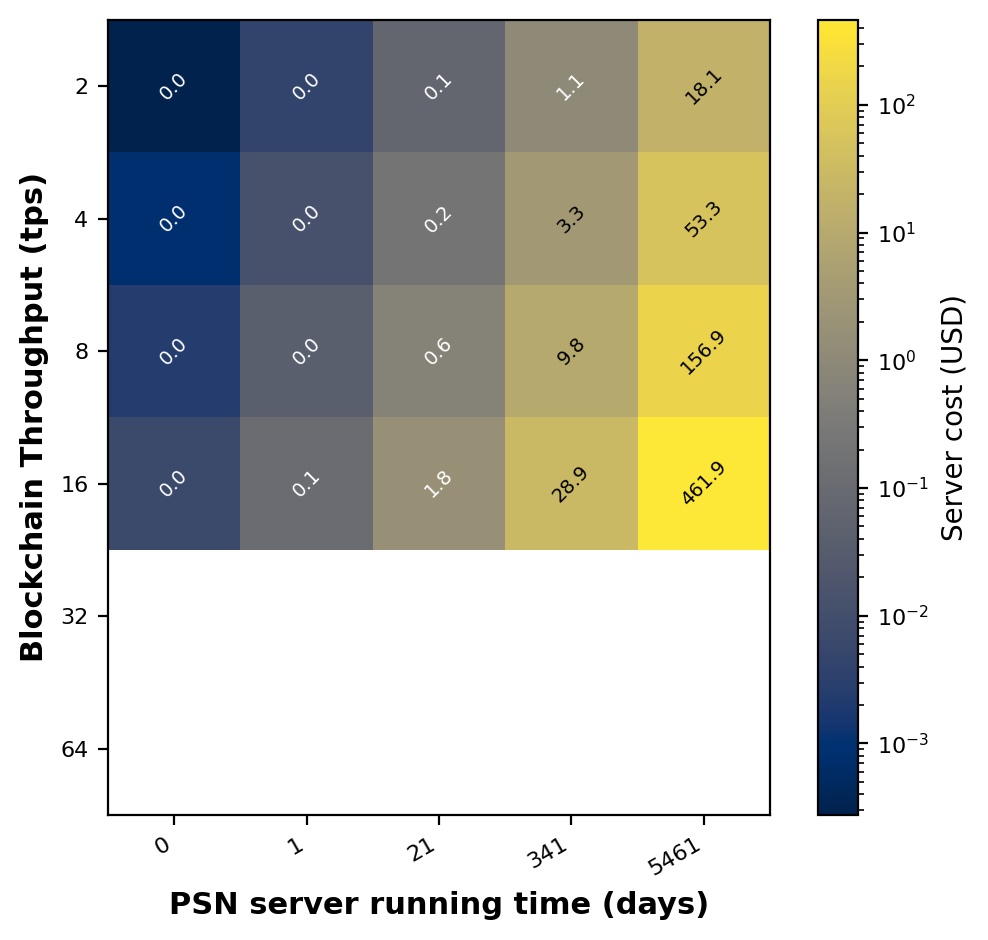

In [176]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

cost_for_plot = np.where(bilinear_upd_cost > 0, bilinear_upd_cost, np.nan)
vmin = float(np.nanmin(cost_for_plot))
vmax = float(np.nanmax(cost_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    cost_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.0f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = bilinear_upd_cost[i, j]
        if value <= 0:
            continue

        label = f"{value:.1f}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Server cost (USD)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_bilinear.pdf", bbox_inches="tight")
plt.show()

In [177]:
## RSA membership proof-delegation

In [178]:
rsa_running_times = np.array(
    [
        165.62647694999998,
        260.1670167,
        439.2490581,
        839.2848875,
        1562.574625,
        3043.0599419,
        3441.5449793000003,
        6883.0211207,
    ],
    dtype=float,
)  ## in miliseconds

x_rsa = np.arange(len(rsa_running_times)) + 3
y_rsa = np.log2(rsa_running_times)

rsa_slope_runtimes, rsa_intercept_runtimes = np.polyfit(x_rsa, y_rsa, 1)
y_rsa_pred = rsa_slope_runtimes * x_rsa + rsa_intercept_runtimes

print(x_rsa.tolist())
print(y_rsa.tolist())
print(f"rsa_intercept_runtimes = {rsa_intercept_runtimes:.6f}")
print(f"rsa_slope_runtimes = {rsa_slope_runtimes:.6f}")

[3, 4, 5, 6, 7, 8, 9, 10]
[7.371789509418317, 8.023294262285635, 8.778895382380792, 9.713016793073328, 10.609709375906611, 11.57130703686167, 11.74884065005245, 12.748826221562604]
rsa_intercept_runtimes = 4.999091
rsa_slope_runtimes = 0.780249


In [179]:
## RSA membership proof-delegation
noOfThreads = 8  ## number of threads at the AWS server machine
g1_group_element_size = 3072  ## in bits
bytes_in_pb = 10**15  ## decimal petabyte
rsa_upd_cost = np.zeros((len(tps), len(server_time)))
rsa_comm_complexity = np.zeros((len(tps), len(server_time)))
for i in range(0, len(tps)):
    for j in range(0, len(server_time)):
        ## for each coin, there were this many new coins added to the UTXO set meanwhile it had not been spent
        necessaryUpdatesPerCoin = average_coin_age_seconds * tps[i]
        ## RSA updates are modeled without the 2**28 CRS cap used above for bilinear.
        runtime_per_update_ms = 2 ** (
            rsa_slope_runtimes * (math.log2(necessaryUpdatesPerCoin))
            + rsa_intercept_runtimes
        )
        updates_per_threads = (tps[i] * runtime_per_update_ms) / noOfThreads
        ## the runtime above were given in miliseconds, thus we need to convert them to hour
        upd_cost_per_hour = (
            updates_per_threads / miliSecondsInHour
        )  ## the workload can be done in parallel
        rsa_upd_cost[i, j] = (
            upd_cost_per_hour * tx3_large_cost_per_hour * server_time[j]
        )  ## let's assume the server is running for 1 year=12 months

        ## Dynamic trapdoorless comm: one 3072-bit element per added element.
        rsa_comm_per_user_pb = (
            g1_group_element_size * necessaryUpdatesPerCoin / 8 / bytes_in_pb
        )
        rsa_comm_complexity[i, j] = (
            server_time[j] * rsa_comm_per_user_pb * tps[i]
        )  ## in PB; scales with the number of added elements
rsa_upd_cost

array([[5.97265567e-01, 9.55624907e+00, 1.52899985e+02, 2.44639976e+03,
        3.91423962e+04],
       [2.05152034e+00, 3.28243255e+01, 5.25189208e+02, 8.40302733e+03,
        1.34448437e+05],
       [7.04667397e+00, 1.12746784e+02, 1.80394854e+03, 2.88631766e+04,
        4.61810825e+05],
       [2.42043001e+01, 3.87268802e+02, 6.19630083e+03, 9.91408132e+04,
        1.58625301e+06],
       [8.31382501e+01, 1.33021200e+03, 2.12833920e+04, 3.40534273e+05,
        5.44854836e+06],
       [2.85567796e+02, 4.56908474e+03, 7.31053558e+04, 1.16968569e+06,
        1.87149711e+07]])

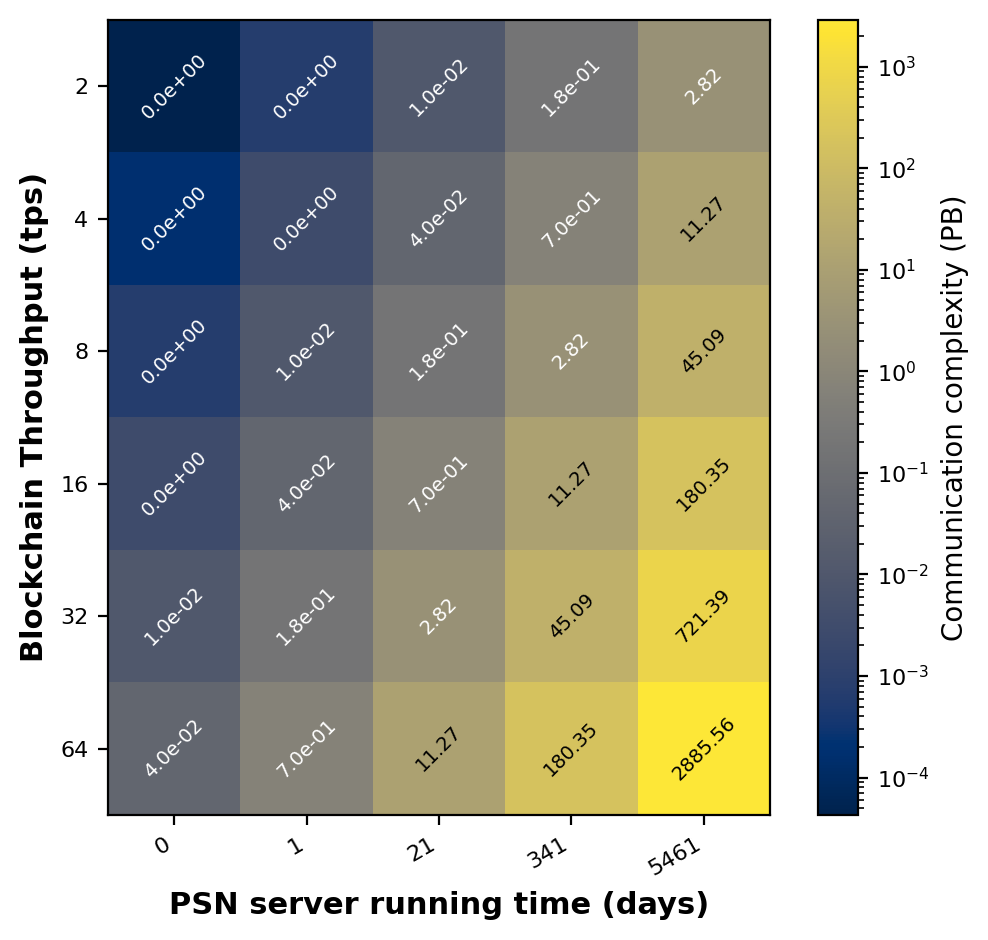

In [180]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

comm_for_plot = np.where(rsa_comm_complexity > 0, rsa_comm_complexity, np.nan)
vmin = float(np.nanmin(comm_for_plot))
vmax = float(np.nanmax(comm_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    comm_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.0f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

# Add subtle cell boundaries for easier reading in print.
ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = rsa_comm_complexity[i, j]
        if value <= 0:
            continue

        label = f"{round(value, 2):.2f}" if value >= 1 else f"{round(value, 2):.1e}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Communication complexity (PB)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_rsa_comm_complexity.pdf", bbox_inches="tight")
plt.show()

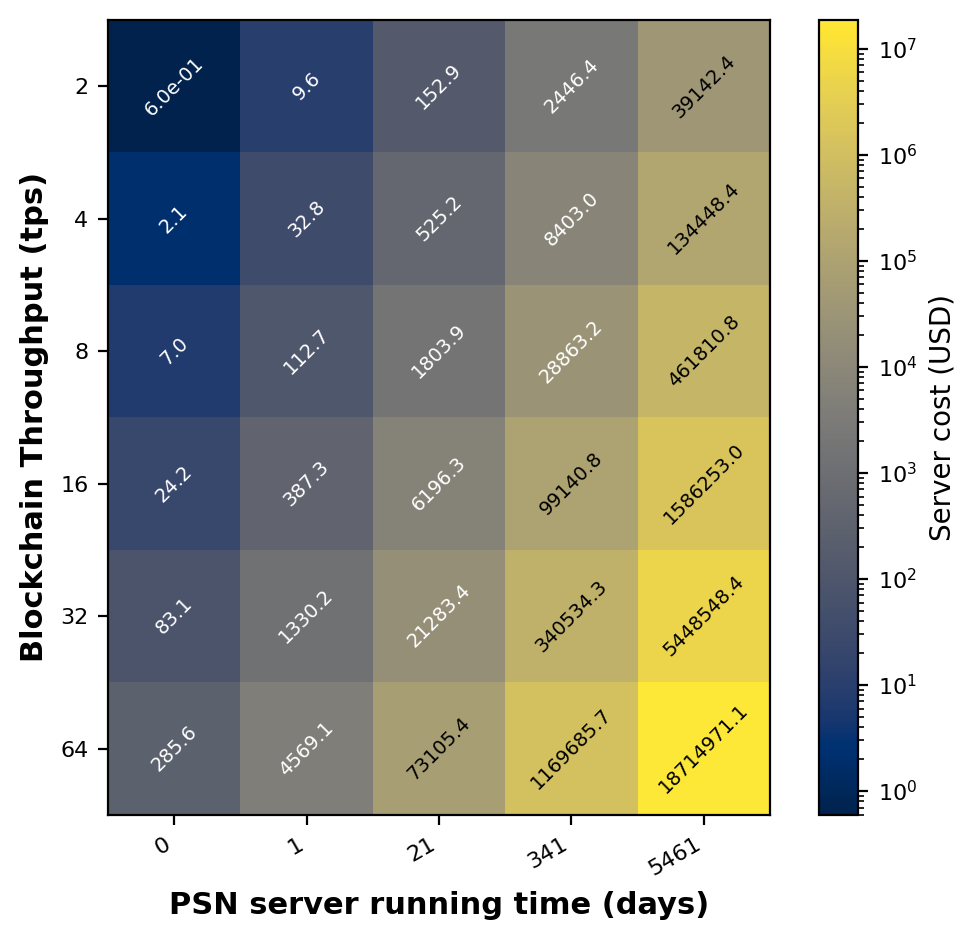

In [181]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

cost_for_plot = np.where(rsa_upd_cost > 0, rsa_upd_cost, np.nan)
vmin = float(np.nanmin(cost_for_plot))
vmax = float(np.nanmax(cost_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    cost_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.0f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = rsa_upd_cost[i, j]
        if value <= 0:
            continue

        label = f"{value:.1f}" if value >= 1 else f"{round(value, 2):.1e}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Server cost (USD)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_rsa_upd_cost.pdf", bbox_inches="tight")
plt.show()

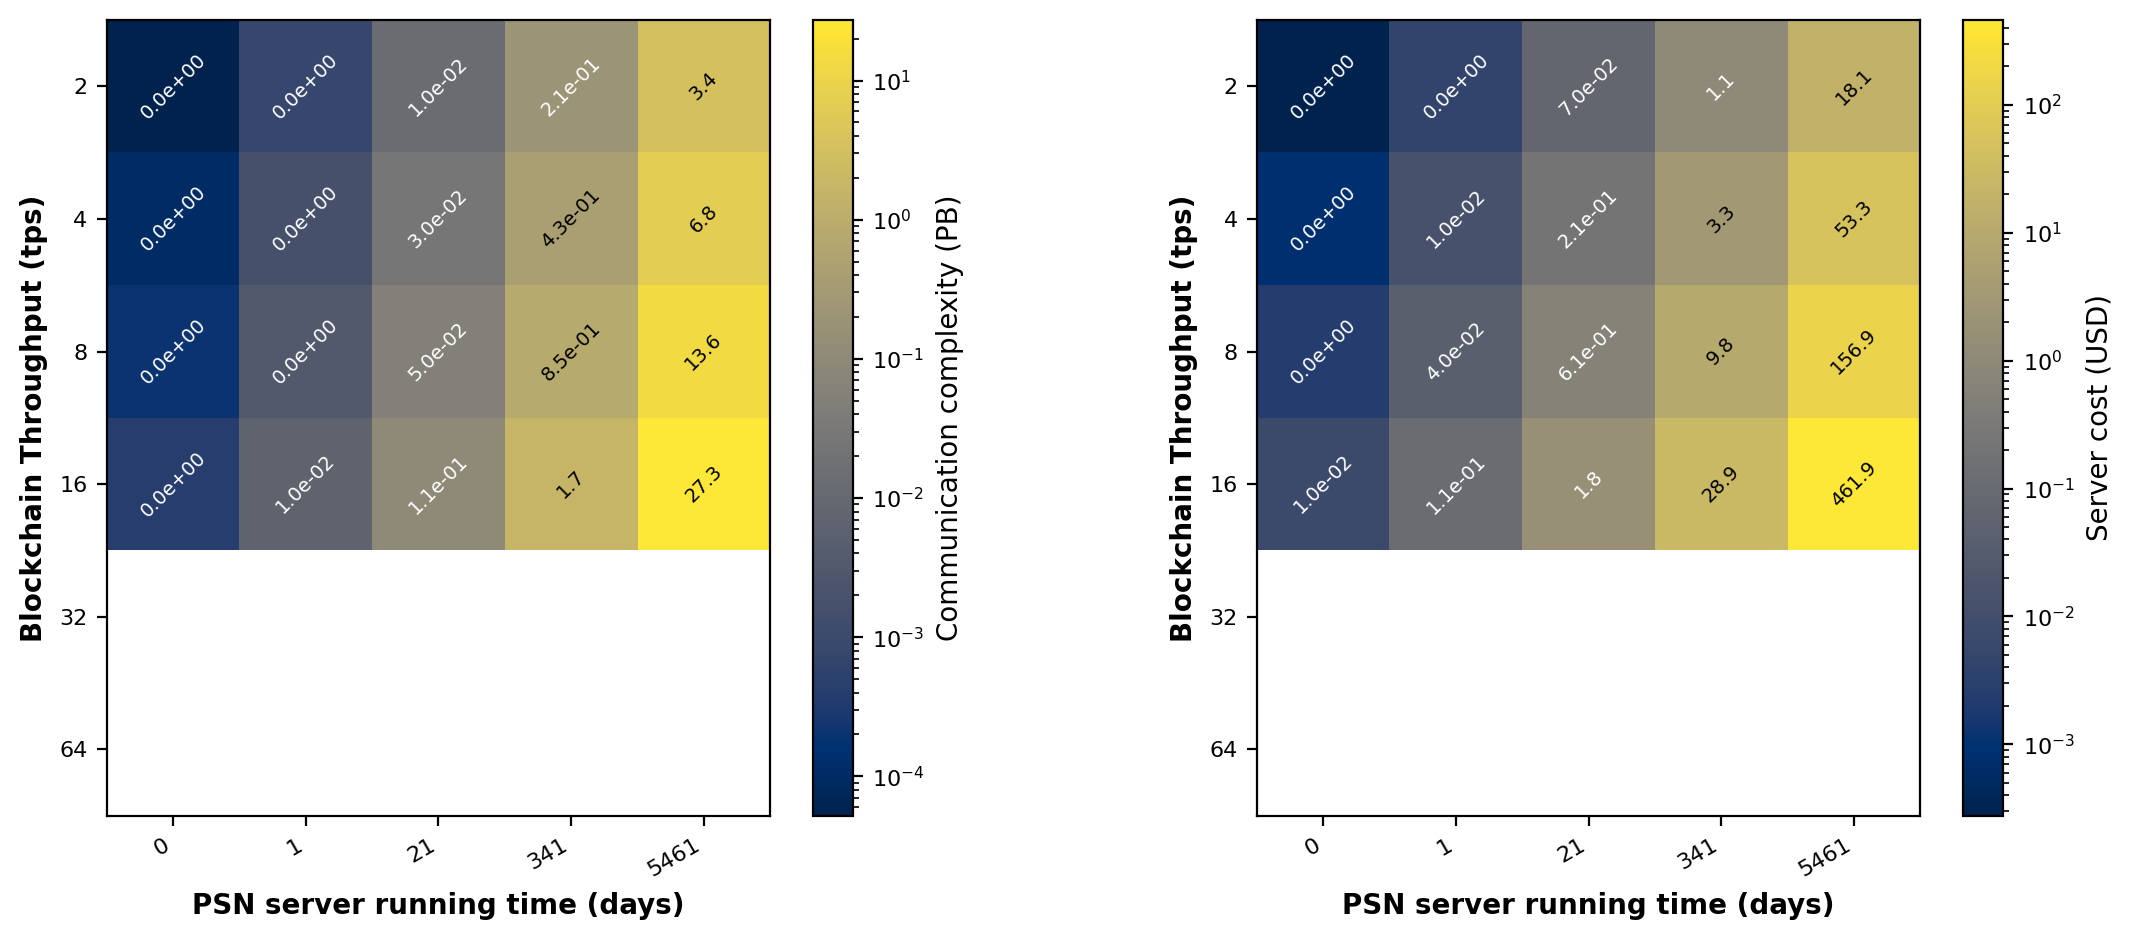

In [ ]:
from matplotlib import ticker
from matplotlib.colors import LogNorm


def draw_log_heatmap(ax, data, cbar_label, day_labels, tps_labels):
    plot_data = np.where(data > 0, data, np.nan)
    cmap = plt.cm.cividis.copy()
    cmap.set_bad("white", alpha=1.0)
    cmap.set_under("white", alpha=1.0)

    vmin = float(np.nanmin(plot_data))
    vmax = float(np.nanmax(plot_data))
    norm = LogNorm(vmin=vmin, vmax=vmax)

    im = ax.imshow(plot_data, cmap=cmap, norm=norm, interpolation="nearest")

    ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=10)
    ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=10)
    ax.set_yticks(range(len(tps_labels)))
    ax.set_yticklabels([str(x) for x in tps_labels], fontsize=8)
    ax.set_xticks(range(len(server_time)))
    ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

    ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
    ax.set_yticks(np.arange(0, len(tps_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(len(tps_labels)):
        for j in range(len(server_time)):
            value = data[i, j]
            if value <= 0:
                continue

            label = f"{value:.1f}" if value >= 1 else f"{round(value, 2):.1e}"
            rgba = cmap(norm(value))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "black" if luminance > 0.58 else "white"
            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=7,
                rotation=45,
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    cbar.locator = ticker.LogLocator(base=10)
    cbar.formatter = ticker.LogFormatterMathtext(base=10)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=8)


day_labels = [f"{h / 24:.0f}" for h in server_time]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), dpi=200)
fig.patch.set_facecolor("white")

draw_log_heatmap(
    axes[0],
    bilinear_comm_complexity,
    "Communication complexity (PB)",
    day_labels,
    tps,
)

draw_log_heatmap(
    axes[1],
    bilinear_upd_cost,
    "Server cost (USD)",
    day_labels,
    tps,
)

fig.tight_layout()
plt.savefig("./images/case_study_bilinear_side_by_side.pdf", bbox_inches="tight")
plt.show()

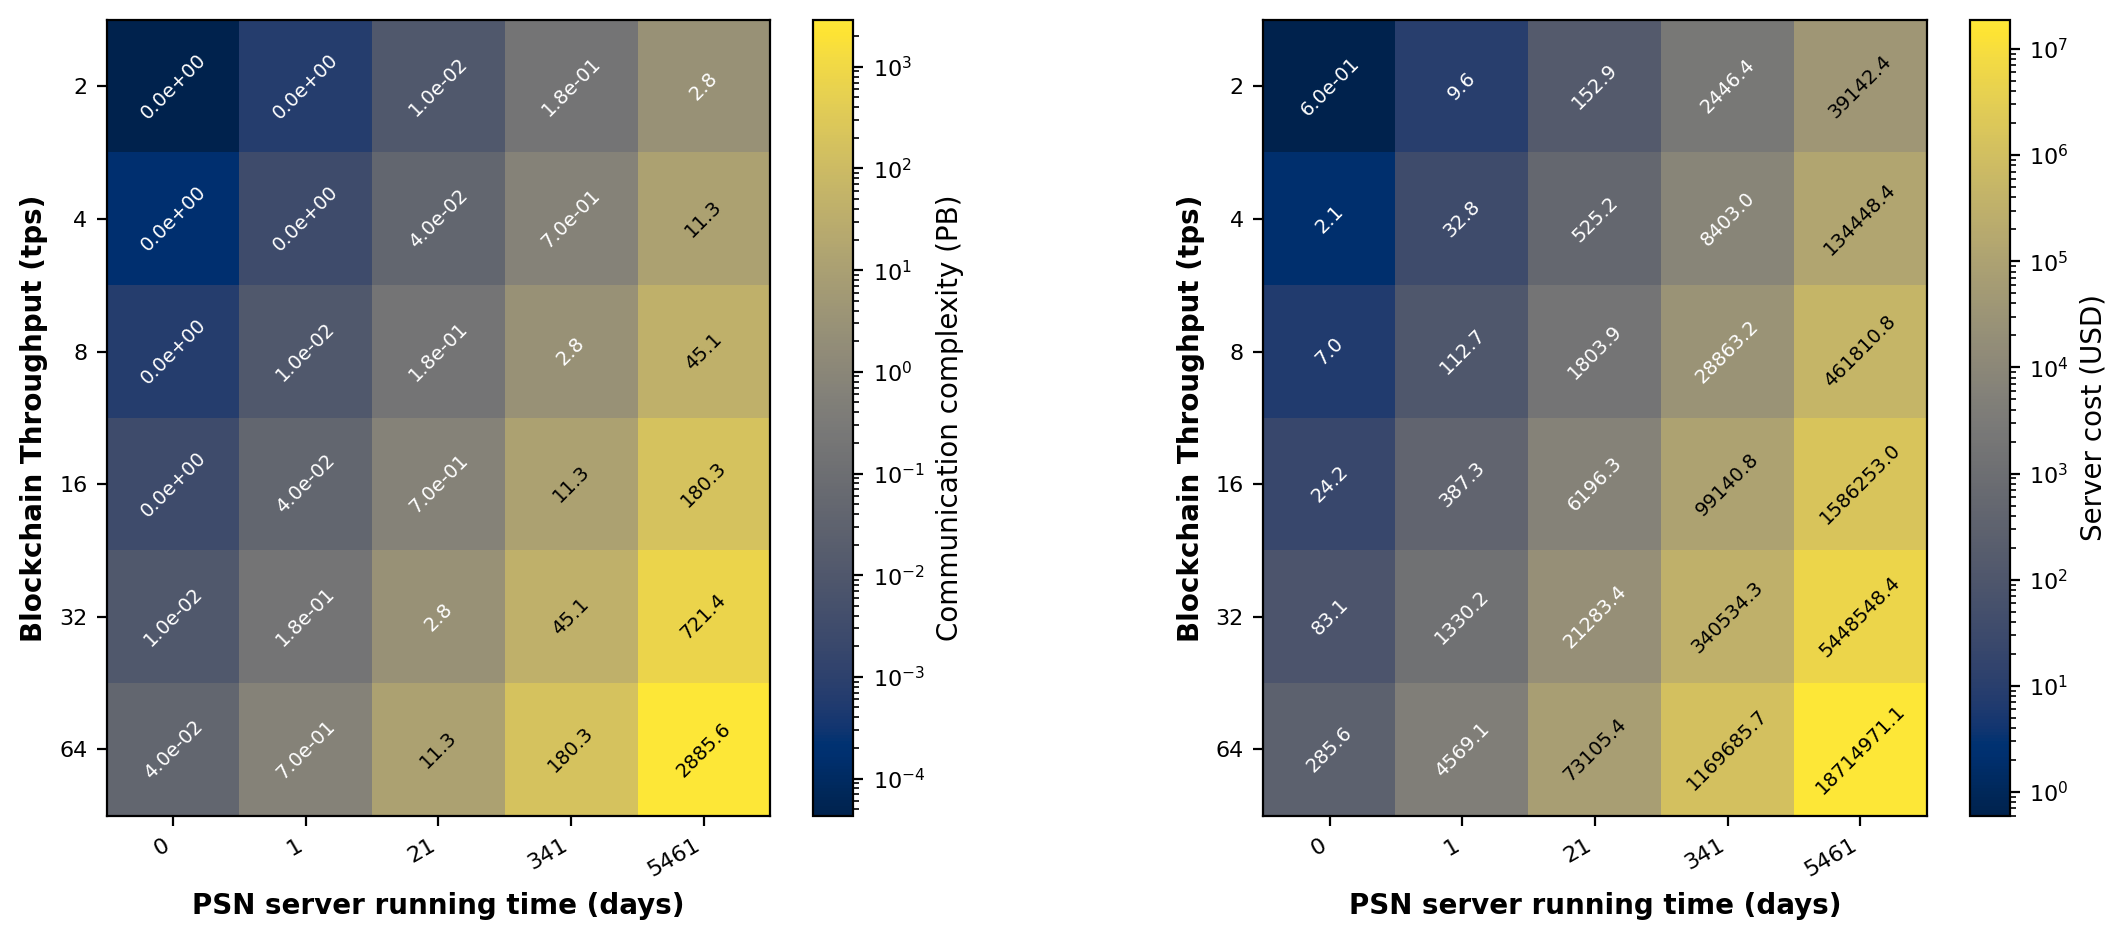

In [183]:
from matplotlib import ticker
from matplotlib.colors import LogNorm


def draw_log_heatmap(ax, data, cbar_label, day_labels, tps_labels):
    plot_data = np.where(data > 0, data, np.nan)
    cmap = plt.cm.cividis.copy()
    cmap.set_bad("white", alpha=1.0)
    cmap.set_under("white", alpha=1.0)

    vmin = float(np.nanmin(plot_data))
    vmax = float(np.nanmax(plot_data))
    norm = LogNorm(vmin=vmin, vmax=vmax)

    im = ax.imshow(plot_data, cmap=cmap, norm=norm, interpolation="nearest")

    ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=10)
    ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=10)
    ax.set_yticks(range(len(tps_labels)))
    ax.set_yticklabels([str(x) for x in tps_labels], fontsize=8)
    ax.set_xticks(range(len(server_time)))
    ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

    ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
    ax.set_yticks(np.arange(0, len(tps_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(len(tps_labels)):
        for j in range(len(server_time)):
            value = data[i, j]
            if value <= 0:
                continue

            label = f"{value:.1f}" if value >= 1 else f"{round(value, 2):.1e}"
            rgba = cmap(norm(value))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "black" if luminance > 0.58 else "white"
            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=7,
                rotation=45,
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    cbar.locator = ticker.LogLocator(base=10)
    cbar.formatter = ticker.LogFormatterMathtext(base=10)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=8)


day_labels = [f"{h / 24:.0f}" for h in server_time]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=200)
fig.patch.set_facecolor("white")

draw_log_heatmap(
    axes[0],
    rsa_comm_complexity,
    "Communication complexity (PB)",
    day_labels,
    tps,
)

draw_log_heatmap(
    axes[1],
    rsa_upd_cost,
    "Server cost (USD)",
    day_labels,
    tps,
)

fig.tight_layout()
plt.savefig("./images/case_study_rsa_side_by_side.pdf", bbox_inches="tight")
plt.show()